In [7]:
import numpy as np
import pandas as pd
import importlib.util
from pathlib import Path

#run from the repo root or Scripts directory
root = Path.cwd()
if root.name == 'Scripts':
    root = root.parent

#local plotting functions
spec = importlib.util.spec_from_file_location('plot_init', root / 'functions' / 'plot_init.py')
plot_init = importlib.util.module_from_spec(spec)
spec.loader.exec_module(plot_init)

#plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [8]:
comp_df = pd.read_csv(root / 'Data' / 'satellite_comparison.csv')

#drop any rows where either 'swh_adjusted' or 'ww3_hs' is nan
comp_df = comp_df.dropna(subset=['swh_adjusted', 'ww3_hs'])
rmse = np.sqrt(np.mean((comp_df['ww3_hs'] - comp_df['swh_adjusted'])**2))
correlation = np.corrcoef(comp_df['ww3_hs'], comp_df['swh_adjusted'])[0,1]

In [9]:
bouycsv = root / 'Data' / 'buoy_metrics.csv'
buoy_df = pd.read_csv(bouycsv)
buoylat = buoy_df['lat'].values
buoylon = buoy_df['lon'].values
buoynames = buoy_df['station'].values


/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/Users/martin.henke/anaconda3/envs/PISCES/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/martin.

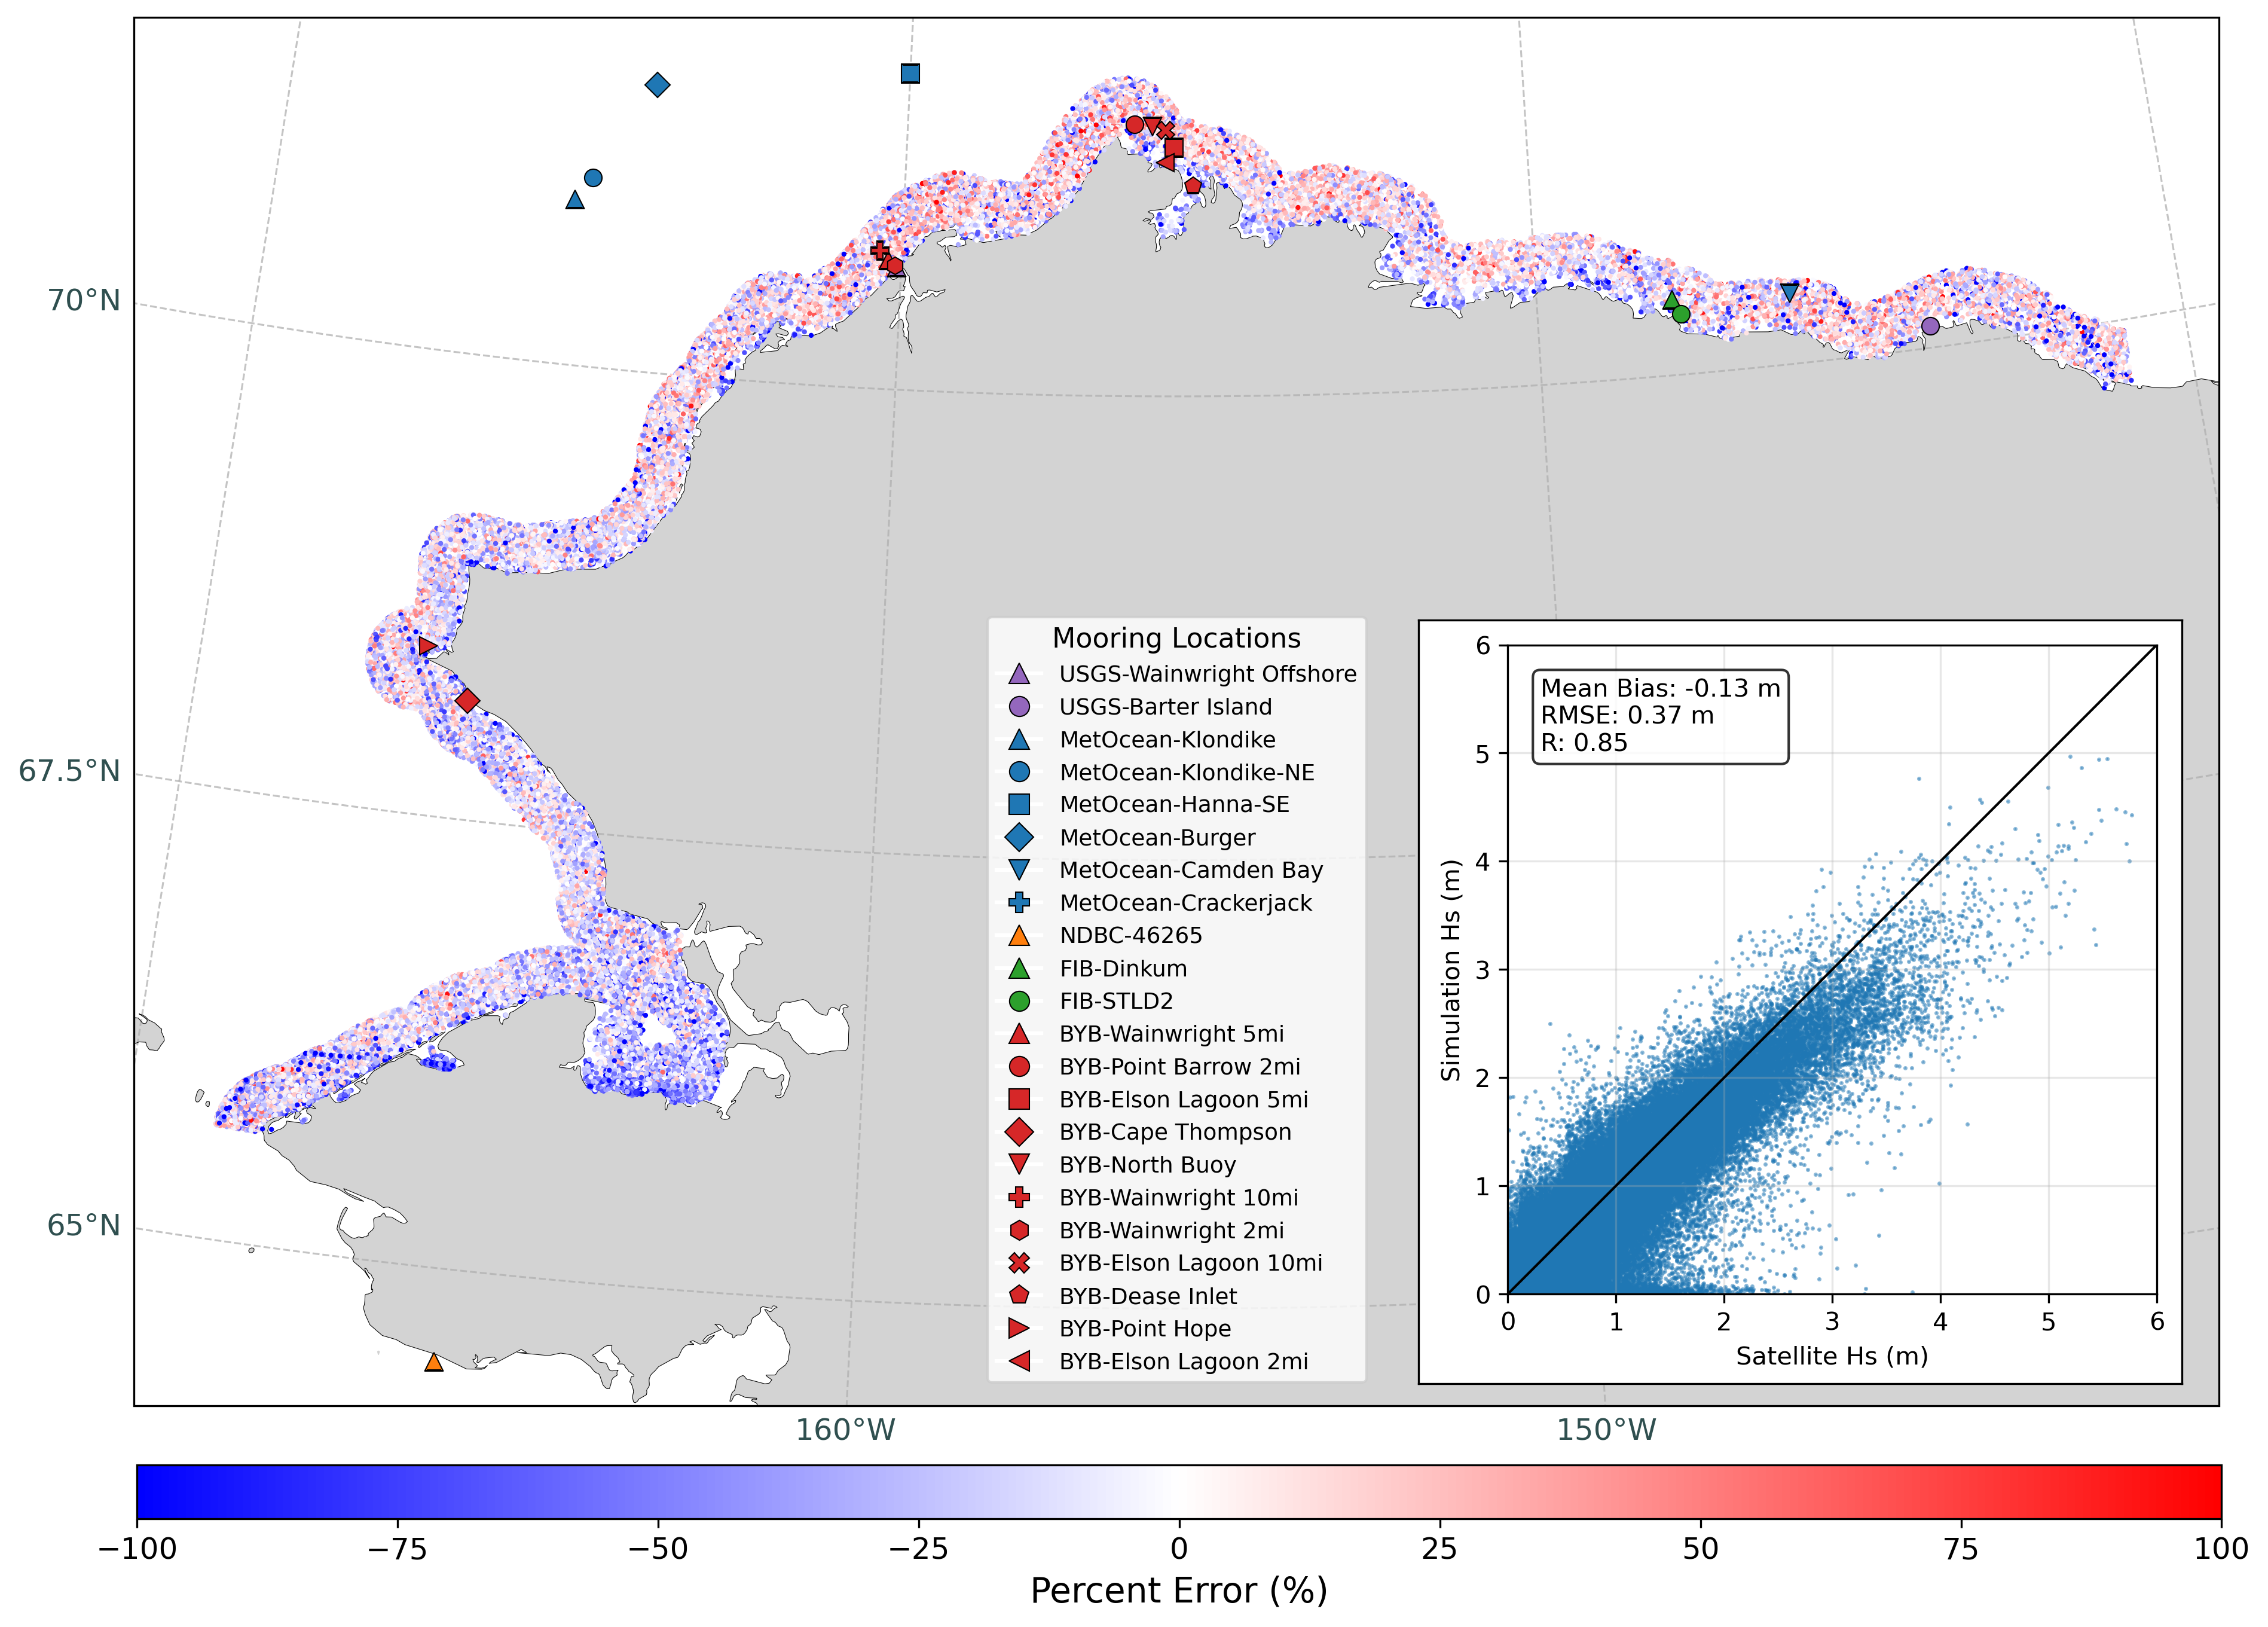

In [10]:

def make_it_nice(ax,extent,proj):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.coastlines(resolution='10m', color='black', linewidth=0.25,zorder=4)

def get_gridlines(ax,region = 'main'):
    if region == 'main':
        xticks = np.arange(-170, 190, 10)
        yticks = np.arange(55, 83, 2.5)
    elif region == 'chukchi':
        xticks = np.arange(-170, -150, 5)
        yticks = np.arange(65, 75, 2)
    elif region == 'beaufort':
        xticks = np.arange(-160, -130, 5)
        yticks = np.arange(67, 73.8, 1)
    else:#raise error
        raise ValueError("Unknown region specified")

    gl = ax.gridlines(draw_labels=True, linestyle='--',
                      xlocs=xticks, ylocs=yticks, alpha=0.75,
                      x_inline=False, y_inline=False,
                      zorder=50, linewidth=0.75,
                      xpadding=10)
    return gl

def gl_styler(gl,l=False,r=False,t=False,b=False):
    gl.bottom_labels = b
    gl.top_labels = t
    gl.right_labels = r
    gl.left_labels = l
    gl.xlabel_style = {'size': 12, 'rotation': 0, 'color': 'darkslategrey','ha':'center'}  # <-- Add pad here
    gl.ylabel_style = {'size': 12, 'rotation': 0, 'color': 'darkslategrey'} 


fig = plt.figure(figsize=(15, 15),dpi=300)
proj0,akextent = plot_init.arctic_projection(option='alaska')
#subtract -2 degrees from the lat 
akextent = (akextent[0], akextent[1], akextent[2]-1, akextent[3])

ax = plt.subplot(1,1,1,projection=proj0)
make_it_nice(ax,akextent,proj0)
gl = get_gridlines(ax,region='main')
gl_styler(gl,l=True,b=True) 
percentdiff = (comp_df['ww3_hs']-comp_df['swh_adjusted'])
sc = ax.scatter(comp_df['lon'], comp_df['lat'], c=percentdiff*100, cmap='bwr', vmin=-100, vmax=100, s=1, transform=ccrs.PlateCarree(), zorder=10)

#Add buoy locations with unique symbols and colors based on station source
# Define colors for each source
source_colors = {
    'MetOcean': '#1f77b4',  # blue
    'NDBC': '#ff7f0e',      # orange
    'FIB': '#2ca02c',       # green
    'BYB': '#d62728',       # red
    'USGS': '#9467bd'      # purple
}

markers = ['^', 'o', 's', 'D', 'v', 'P', 'h', 'X', 'p', '>', '<']

# Get unique stations in order of appearance
unique_stations = []
for station in buoynames:
    if station not in unique_stations:
        unique_stations.append(station)

# Group stations by source
source_groups = {}
for station in unique_stations:
    source = buoy_df.loc[buoy_df['station'] == station, 'source'].values[0]
    if source not in source_groups:
        source_groups[source] = []
    source_groups[source].append(station)

# Maintain order by source appearance
ordered_sources = []
for station in unique_stations:
    source = buoy_df.loc[buoy_df['station'] == station, 'source'].values[0]
    if source not in ordered_sources:
        ordered_sources.append(source)

buoy_handles = []
for source in ordered_sources:
    color = source_colors[source]
    stations = source_groups[source]
    
    for idx, station in enumerate(stations):
        marker = markers[idx % len(markers)]
        station_mask = buoynames == station
        
        # Get the plotname for this station
        plotname = buoy_df.loc[buoy_df['station'] == station, 'plotname'].values[0]
        
        for i in np.where(station_mask)[0]:
            ax.plot(buoylon[i], buoylat[i], marker=marker, color=color, 
                    markersize=7, markeredgecolor='black', markeredgewidth=0.5,
                    transform=ccrs.PlateCarree(), zorder=20)
        
        # Create handle for legend using plotname
        buoy_handles.append(plt.Line2D([0], [0], marker=marker, color='w', 
                                       markerfacecolor=color, markersize=8,
                                       markeredgecolor='black', markeredgewidth=0.5,
                                       label=plotname))


#sub_ax_box = inset_axes(parent_axes= ax, width='40%', height='40%', loc='lower right',borderpad=1)
sub_ax_box = inset_axes(parent_axes=ax, width='100%', height='100%', 
                        bbox_to_anchor=(0.53, 0.025, 0.55, 0.55), 
                        bbox_transform=ax.transAxes)
[sub_ax_box.spines[k].set_visible(True) for k in sub_ax_box.spines]
sub_ax_box.tick_params(axis='both', left='off', top='off', right='off', bottom='off', labelleft='off', labeltop='off', labelright='off', labelbottom='off')
sub_ax_box.xaxis.set_ticks([])
sub_ax_box.yaxis.set_ticks([])
sub_ax_box.set_facecolor([1,1,1,1])
sub_ax_box.set_aspect('equal')
sub_ax = inset_axes(parent_axes= sub_ax_box, width='85%', height='85%', loc='upper right',borderpad=1)

# Add scatter plot in inset
sub_ax.scatter(comp_df['swh_adjusted'], comp_df['ww3_hs'], alpha=0.5, s=0.5)
sub_ax.plot([0,8],[0,8], 'k', linewidth=1)
sub_ax.set_xlim(0,6)
sub_ax.set_ylim(0,6)
sub_ax.set_xlabel('Satellite Hs (m)', fontsize=10)
sub_ax.set_ylabel('Simulation Hs (m)', fontsize=10)
sub_ax.grid(True, alpha=0.3)

hs_diff = comp_df['ww3_hs'] - comp_df['swh_adjusted']

# Add statistics text to inset
stats_text = f'Mean Bias: {np.mean(hs_diff):.2f} m\nRMSE: {rmse:.2f} m\nR: {correlation:.2f}'
sub_ax.text(0.05, 0.95, stats_text, transform=sub_ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Add legend for buoy stations next to the inset
legend_ax = inset_axes(parent_axes=ax, width='100%', height='100%', 
                       bbox_to_anchor=(0.41, 0.285, 0.2, 0.3), 
                       bbox_transform=ax.transAxes)
legend_ax.axis('off')
legend_ax.legend(handles=buoy_handles, loc='upper left', fontsize=9, 
                frameon=True, shadow=False, title='Mooring Locations',
                title_fontsize=11)

cbar_ax = fig.add_axes([0.126, 0.195, 0.775, 0.02])  # [left, bottom, width, height]
cbar = plt.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Percent Error (%)', fontsize=14)
cbar.ax.tick_params(labelsize=12)

#save it
fig.savefig(root / 'Figures' / 'satellite_validation.png', dpi=300, bbox_inches='tight')


